In [7]:
#Libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.metrics import confusion_matrix, classification_report


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
#Data Loading from torchvision
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.25, 0.25, 0.25))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.25, 0.25, 0.25))
])

#Load the underlying data ONCE (no transform yet) to avoid downloading/loading twice
base_train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=None)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

class TransformSubset(torch.utils.data.Dataset):
    """Wraps a Subset of a transform-less dataset and applies a transform on the fly,
    so train/val can share the same underlying CIFAR10 download with different transforms."""
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

train_size = 45000
val_size = 5000

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(base_train_set), generator=generator).tolist()

train_dataset = TransformSubset(base_train_set, indices[:train_size], transform_train)
val_dataset = TransformSubset(base_train_set, indices[train_size:], transform_test)

NUM_WORKERS = 0

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1024, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1024, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=1024, shuffle=False,
    num_workers=NUM_WORKERS
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.5].


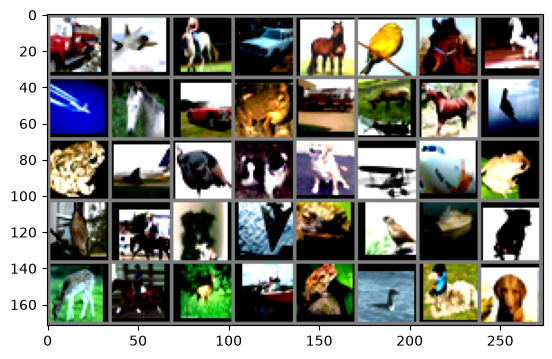

In [10]:
#Defining Classes from CIFAR 10
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#Verifying whether the data is loaded
def img_show(img):
    img=img/2+0.5 #To unnormalize as its needed for viewing
    img = img.numpy() #Needed for changing from tensor to numpy
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.show()
    
data_iter = iter(train_loader)
images, labels = next(data_iter)
img_show(torchvision.utils.make_grid(images[:40]))

In [11]:
#Defining the Model
class Block(nn.Module):
        def __init__(self, in_channels, out_channels, stride=1):
            super().__init__()

            self.conv1 = nn.Conv2d(in_channels, out_channels,kernel_size=3,stride=stride,padding=1,bias=False)
            self.bn1 = nn.BatchNorm2d(out_channels)

            self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
            self.bn2 = nn.BatchNorm2d(out_channels)

            self.relu = nn.ReLU(inplace=True)

            self.shortcut = nn.Sequential()

            if stride != 1 or in_channels != out_channels:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=stride,bias=False),
                    nn.BatchNorm2d(out_channels)
                )

        def forward(self, x):
            identity = self.shortcut(x)

            out = self.relu(self.bn1(self.conv1(x)))
            out = self.bn2(self.conv2(out))

            out += identity
            out = self.relu(out)

            return out

In [ ]:
class ResNet(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.stage1 = nn.Sequential(
             Block(32, 32),
             Block(32, 32)
        )

        self.stage2 = nn.Sequential(
             Block(32, 64, stride=2),
             Block(64, 64)
        )

        self.stage3 = nn.Sequential(
             Block(64, 128, stride=2),
             Block(128, 128)
        )
        
        self.stage4 = nn.Sequential(
             Block(128, 256, stride=2),
             Block(256, 256)
        )
        
        #Global Average Pooling
        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.fc(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet().to(device)

criterion = nn.CrossEntropyLoss()

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay=5e-4) didn't work well thus removed
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)


  train batch 0/44
  train batch 5/44
  train batch 10/44
  train batch 15/44
  train batch 20/44
  train batch 25/44
  train batch 30/44
  train batch 35/44
  train batch 40/44
Epoch [1/20] | Train Loss: 1.9226 | Train Acc: 29.71% | Val Loss: 1.6679 | Val Acc: 39.46%
  train batch 0/44
  train batch 5/44
  train batch 10/44
  train batch 15/44
  train batch 20/44
  train batch 25/44
  train batch 30/44
  train batch 35/44
  train batch 40/44
Epoch [2/20] | Train Loss: 1.4459 | Train Acc: 46.27% | Val Loss: 1.6027 | Val Acc: 43.98%
  train batch 0/44
  train batch 5/44
  train batch 10/44
  train batch 15/44
  train batch 20/44
  train batch 25/44
  train batch 30/44
  train batch 35/44
  train batch 40/44
Epoch [3/20] | Train Loss: 1.2133 | Train Acc: 56.04% | Val Loss: 1.3018 | Val Acc: 54.96%
  train batch 0/44
  train batch 5/44
  train batch 10/44
  train batch 15/44
  train batch 20/44
  train batch 25/44
  train batch 30/44
  train batch 35/44
  train batch 40/44
Epoch [4/20] | 

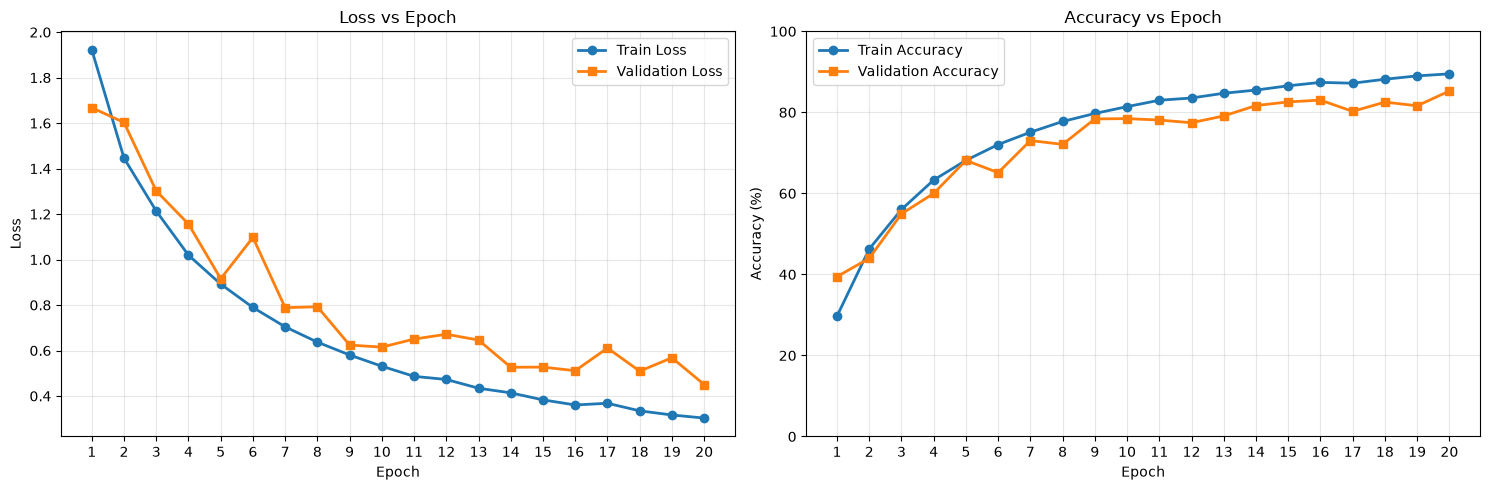

In [ ]:
def train_model(train_loader, val_loader):
    epochs = 20

    train_losses = []
    train_accs = []

    val_losses = []
    val_accs = []

    best_val_acc = 0

    for epoch in range(epochs):

        #Train
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for i, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if i % 5 == 0:
                print(f"  train batch {i}/{len(train_loader)}", flush=True)

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_accuracy)

        #Validation
        model.eval()

        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_val_loss / len(val_loader)
        val_accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accs.append(val_accuracy)

        # Save best model
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), "best_model.pth")

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

    epochs_range = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss Plot
    ax1.plot(epochs_range, train_losses, marker='o', linewidth=2,
            label='Train Loss')
    ax1.plot(epochs_range, val_losses, marker='s', linewidth=2,
            label='Validation Loss')

    ax1.set_title("Loss vs Epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_xticks(list(epochs_range))
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Accuracy Plot
    ax2.plot(epochs_range, train_accs, marker='o', linewidth=2,
            label='Train Accuracy')
    ax2.plot(epochs_range, val_accs, marker='s', linewidth=2,
            label='Validation Accuracy')

    ax2.set_title("Accuracy vs Epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_xticks(list(epochs_range))
    ax2.set_ylim(0, 100)
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

train_model(train_loader, val_loader)


In [15]:
#Loading the best saved model for testing
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

predictions = []
targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        predictions.extend(predicted.cpu().numpy())
        targets.extend(labels.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")
print(classification_report(targets, predictions, target_names=classes))


Test Accuracy: 85.26%
              precision    recall  f1-score   support

       plane       0.89      0.85      0.87      1000
         car       0.98      0.84      0.90      1000
        bird       0.82      0.78      0.80      1000
         cat       0.71      0.78      0.74      1000
        deer       0.81      0.88      0.85      1000
         dog       0.78      0.82      0.80      1000
        frog       0.92      0.85      0.88      1000
       horse       0.92      0.85      0.89      1000
        ship       0.88      0.94      0.91      1000
       truck       0.87      0.95      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



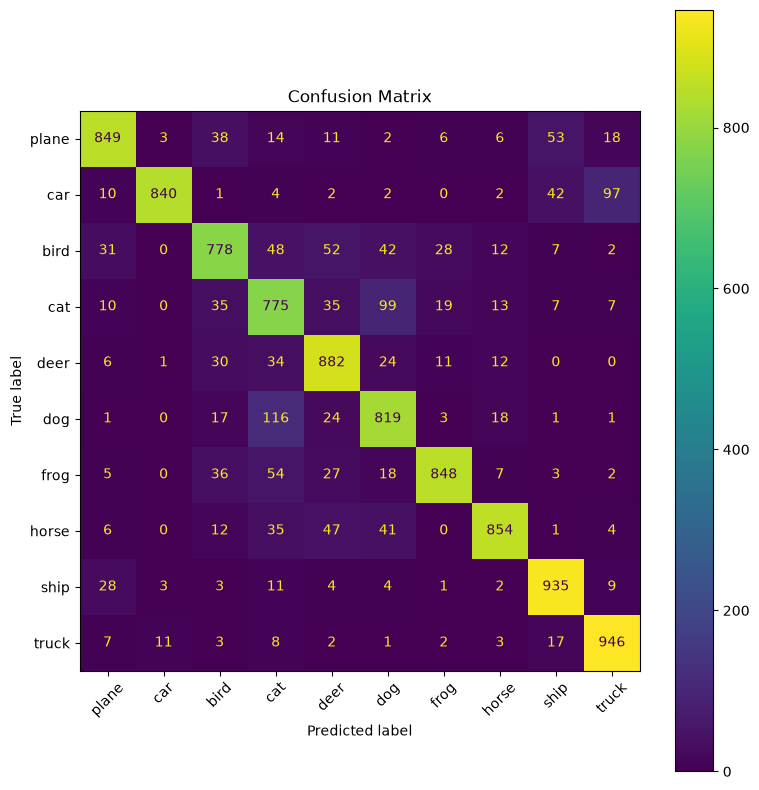

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(targets, predictions)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Why residual connections help optimization
 stacking many convolutional layers creates the degradation problem ie past a certain depth, adding more layers makes training error go up, not down, this is an optimization failure, not overfitting. Each Block in the implementation reframes its job as learning a residual F(x) on top of the identity: out = F(x) + identity. If the ideal mapping for a block is close to identity, it's trivial for the block to drive F(x) toward zero (small weights), which is far easier than forcing a stack of conv-BN-ReLU layers to approximate an identity function directly.

### How skip connections improve gradient flow
During backpropagation, out = F(x) + identity means the gradient has an unimpeded additive path back through the shortcut: ∂loss/∂x gets a +1 contribution regardless of what happens in the conv branch. This mitigates vanishing gradients and gradients don't either implode or explode.

### Effect of network depth on performance
Deeper networks have a tradeoff for higher performance against longer and slower epochs.

### Some Challenges
Dimension Mismatches were the most common type of challenge, also dataloader function configuration of Number of workers to train the model fast enough was quite hard.